<div style="border: solid red 2px; padding: 20px">
    
# Анализ клиентской базы сети фитнес-центров

Задача
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. 
Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще перестают пользоваться сервисом тихо.

Индикаторы оттока зависят от специфики отрасли. Когда пользователь редко, но стабильно закупается в интернет-магазине — не похоже, что он «отвалился». А вот если две недели не заходит на канал с ежедневно обновляемым контентом, дела плохи: подписчик заскучал и, кажется, оставил вас. 
Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал. Конечно, не исключено, что он уехал на Бали и по приезде обязательно продолжит ходить на фитнес. Однако чаще бывает наоборот. Если клиент начал новую жизнь с понедельника, немного походил в спортзал, а потом пропал — скорее всего, он не вернётся. 

Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. Наша задача — провести анализ и подготовить план действий по удержанию клиентов.  

А именно: 

- научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
- проанализировать основные признаки, наиболее сильно влияющие на отток;
- сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:

1) выделить целевые группы клиентов;
2) предложить меры по снижению оттока;
3) определить другие особенности взаимодействия с клиентами.

---

**Описание данных**

Данные клиента за предыдущий до проверки факта оттока месяц:

- `gender` — пол;
- `Near_Location` — проживание или работа в районе, где находится фитнес-центр;
- `Partner` — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
- `Promo_friends` — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
- `Phone` — наличие контактного телефона;
- `Age` — возраст;
- `Lifetime` — время с момента первого обращения в фитнес-центр (в месяцах).

Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:

- `Contract_period` — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- `Month_to_end_contract` — срок до окончания текущего действующего абонемента (в месяцах);
- `Group_visits` — факт посещения групповых занятий;
- `Avg_class_frequency_total` — средняя частота посещений в неделю за все время с начала действия абонемента;
- `Avg_class_frequency_current_month` — средняя частота посещений в неделю за предыдущий месяц;
- `Avg_additional_charges_total` — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
- `Churn` — факт оттока в текущем месяце.

---
    
**Ход исследования**
    
Данные получим из файла: `/datasets/gym_churn.csv`. О качестве датасета информации нет. Перед тем как приступать к цели исследования, нам необходимо изучить данные.
    
Проверим данные на предмет ошибок и оценим их влияние на результаты исследования. В процессе преодобработки данных попробуем исправить все ошибки, которые могут привести к искажению конечного результата. Далее мы приоритизируем гипотезы и выводы на подходящих графиках и приступим к анализу результатов А/В теста и выявлению закономерностей.
    
Таким образом, мое исследование пройдет в следующие этапы:
    
- Загрузка и предобработка данных.
- Исследовательский анализ данных.
- Исследование средних значений признаков среди двух групп - отвалившихся и лояльных клиентов.
- Построение двух моделей прогнозирования оттока клиентов.
- Кластеризация клиентов, сравнение признаков каждого кластера и подсчет доли оттока клиентов по  каждому кластеру.
- Формулировка выводов и базовых рекомендаций по работе с клиентами.

# Шаг 1. Загрузка данных

Импортируем необходимые нам библиотеки для изучения общей информации и предобработки данных.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

Сохраним файл с данными в датафрейм.

In [6]:
try:
    clients = pd.read_csv('/datasets/gym_churn.csv')
except:
    clients = pd.read_csv('C:/Users/etols/Downloads/gym_churn.csv')

***ВЫВОДЫ:***

1. Мы импортировали необходимые библиотеки для предобработки и первичного анализа данных.
2. Мы загрузили необходимые нам данные и сохранили их в датафрейм.

# Шаг 2. Исследовательский анализ данных (EDA)

### 2.1. Посмотрим на датасет: есть ли в нём отсутствующие значения (пропуски), изучим средние значения и стандартные отклонения с помощью метода describe()

Изучим общие данные о датасете с помощью функции для проведения первичной предобработки данных.

In [11]:
def review(data):
    print(data.info())
    print('--------------------')
    display(data.head())
    print('--------------------')
    display(data.describe().T)
    print('--------------------')
    print(data.isna().sum())
    print('--------------------')
    print('Дубликатов в данных:', data.duplicated().sum())

In [12]:
review(clients)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


--------------------


,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


--------------------
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64
--------------------
Дубликатов в данных: 0


Сразу видим, что названия столбцов в датафрейме clients указаны с большой буквы, приведем их к нижнему регистру.

In [14]:
clients.columns = [x.lower().replace(' ', '_') for x in clients.columns.values]
clients.sample()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
3759,0,1,0,0,1,12,1,28,106.905945,8.0,6,2.857143,2.699359,0


***Контингент фитнес-клуба - это клиенты в возрасте от 18 до 41 года. Частота посещений фитнес-клуба клиентами составляет от 0 до 6 раз в неделю.***

### 2.2. Посмотрим на средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался с помощью метода groupby()

In [17]:
clients.groupby(['churn']).mean().T

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


***Изучив средние значения признаков в группах ушедших в отток клиентов и оставшихся клиентов, мы увидели, что многие признаки влияют на отток клиента сильнее:***

- `gender`: примерно одинаковая доля мужчин и женщин попала в обе группы, пол не особо влияет на процент оттока клиентов
- `near_location`: практически все клиенты проживают или работают в районе местонахождения фитнес-центра
- `partner`: чаще остаются клиентами клуба сотрудники компаний-партнеров клуба
- `promo_friends`: те клиенты, которые пришли в рамках акции "Приведи друга", реже перестают в итоге быть его клиентами
- `contract_period`: чем на больший период клиент приобретает абонемент, тем реже он попадает в группу оттока
- `group_visits`: клиенты, которые посещают групповые тренировки, реже отваливаются
- `age`: средний возраст клиентов из двух групп практически одинаковый, делаем вывод, что не особо можно выделить взаимосвязь возраста и факта оттока клиентов
- `avg_additional_charges_total`: чаще пользуются дополнительными услугами фитнес-клуба те клиенты, которые реже отваливаются
- `month_to_end_contract`: чем меньше времени осталось до конца абонемента, тем чаще клиенты бросают занятия в фитнес-клубе, что в принципе логично
- `lifetime`: чем дольше человек является клиентом фитнес-клуба, тем реже он пеерходит куда-то в другое место
- `avg_class_frequency_total` и `avg_class_frequency_current_month`: чем больше посещений в неделю у клиента, тем реже он уходит в отток, результаты похожи как с начала действия абонемента, так и за текущий месяц 

Еще очень интересно предположить, какой именно пол обозначается `0`, а какой `1`, раз в данных об этом нет информации. 

In [20]:
clients.groupby(['group_visits'], as_index=False).agg({'gender':'count'})

,group_visits,gender
0,0,2351
1,1,1649


***Обычно на групповые занятия чаще ходят женщины, поэтому могу предположить, что `0` в наших данных - это женщины. Но никаких подтверждений в наших даных этой гипотезе, к сожалению, нет.***

### 2.3. Построим столбчатые гистограммы и распределения признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток)

Для булевых значений построим для наглядности столбчатые диаграммы: 

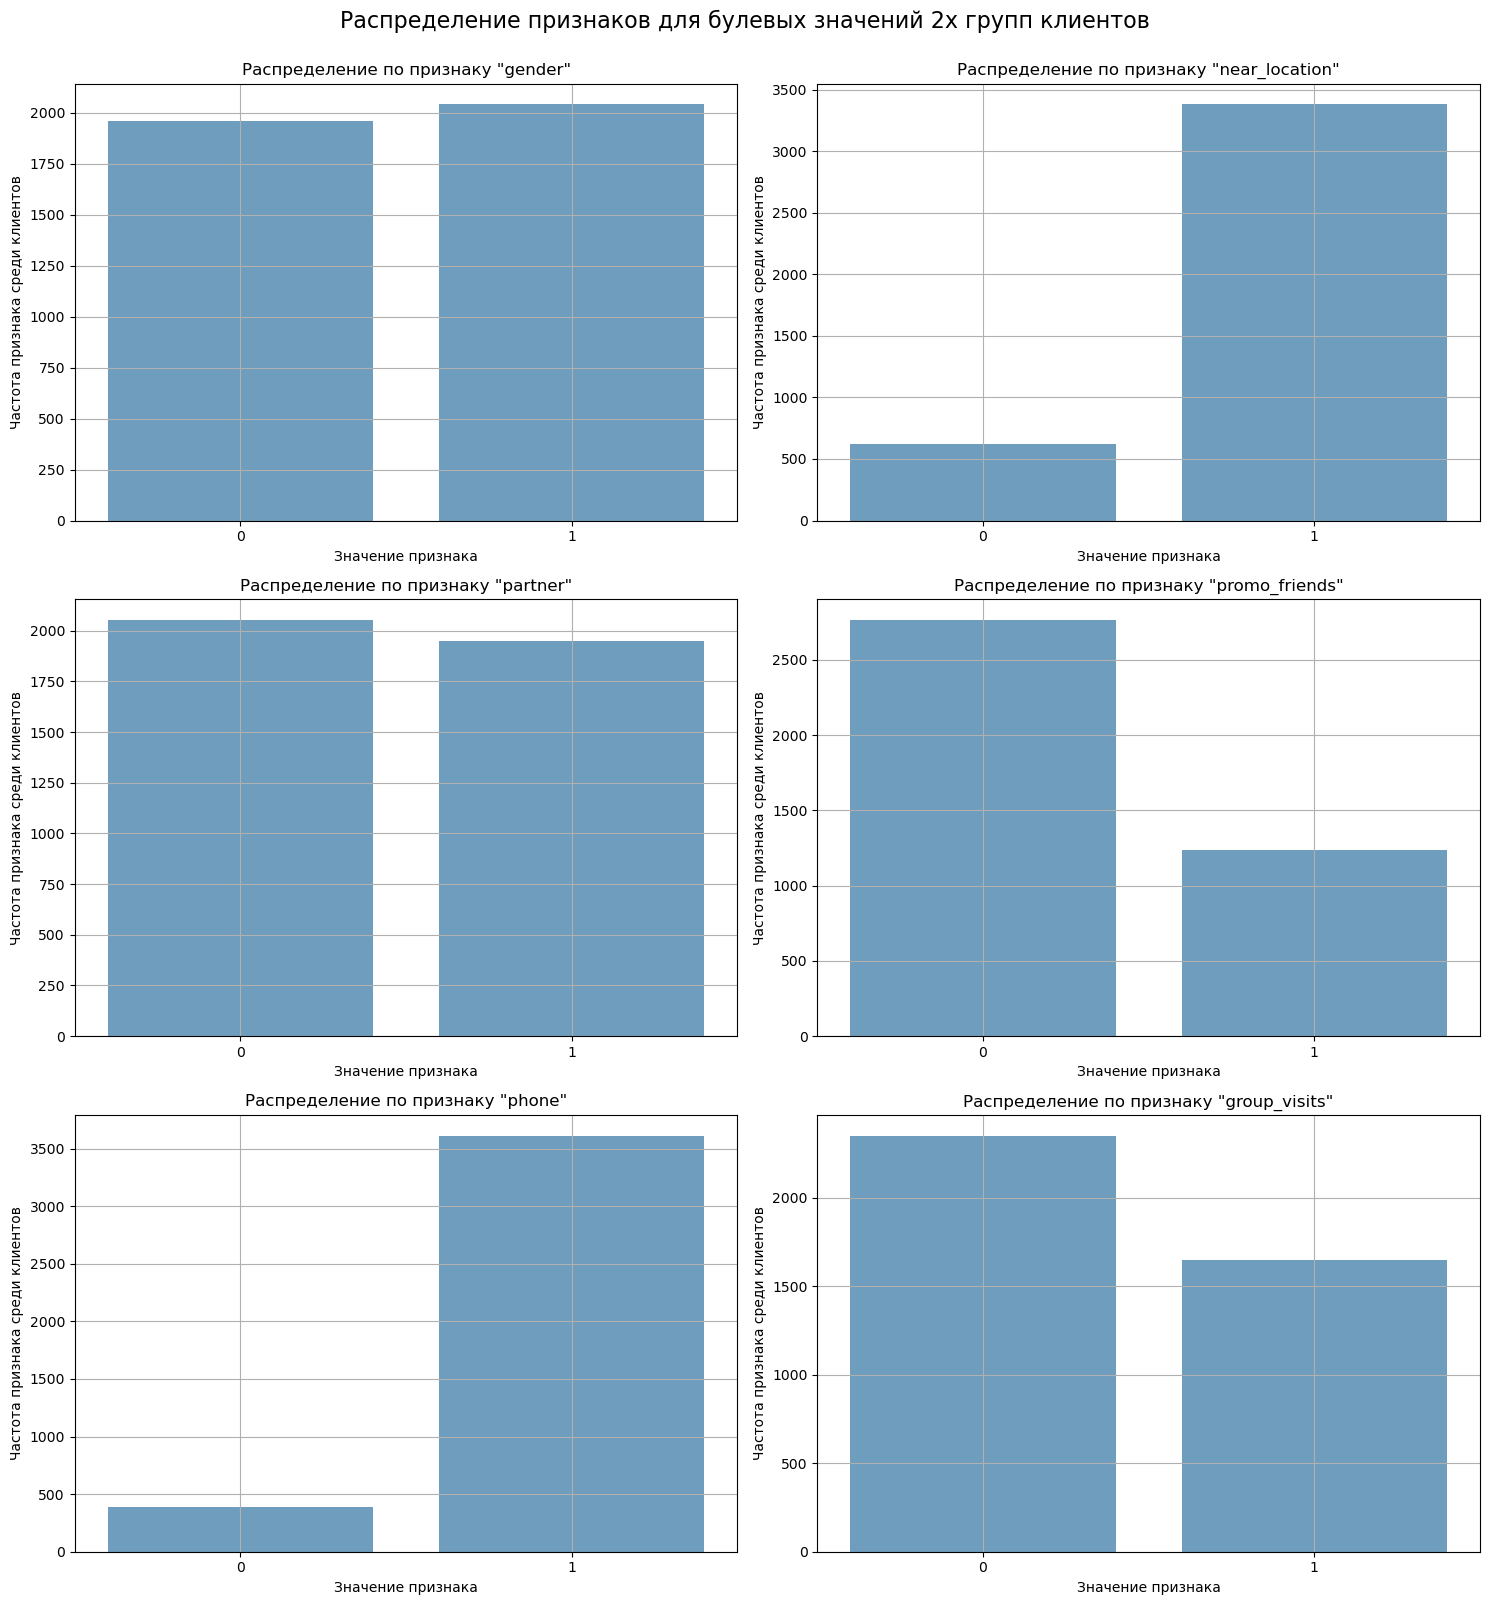

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 16)) 
fig.suptitle('Распределение признаков для булевых значений 2х групп клиентов', fontsize=16, y=1)

values = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits']

# Проходим по всем признакам, кроме 'churn' и строим графики
for idx, column in enumerate(values):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    sns.countplot(x=clients[column], data=clients, ax=ax, alpha=0.7)
    
    ax.set_ylabel('Частота признака среди клиентов')
    ax.set_xlabel('Значение признака')
    ax.set_title(f'Распределение по признаку "{column}"')
    ax.grid(True)
    
plt.tight_layout()
plt.show()

Для остальных величин построим гистограммы распределения:

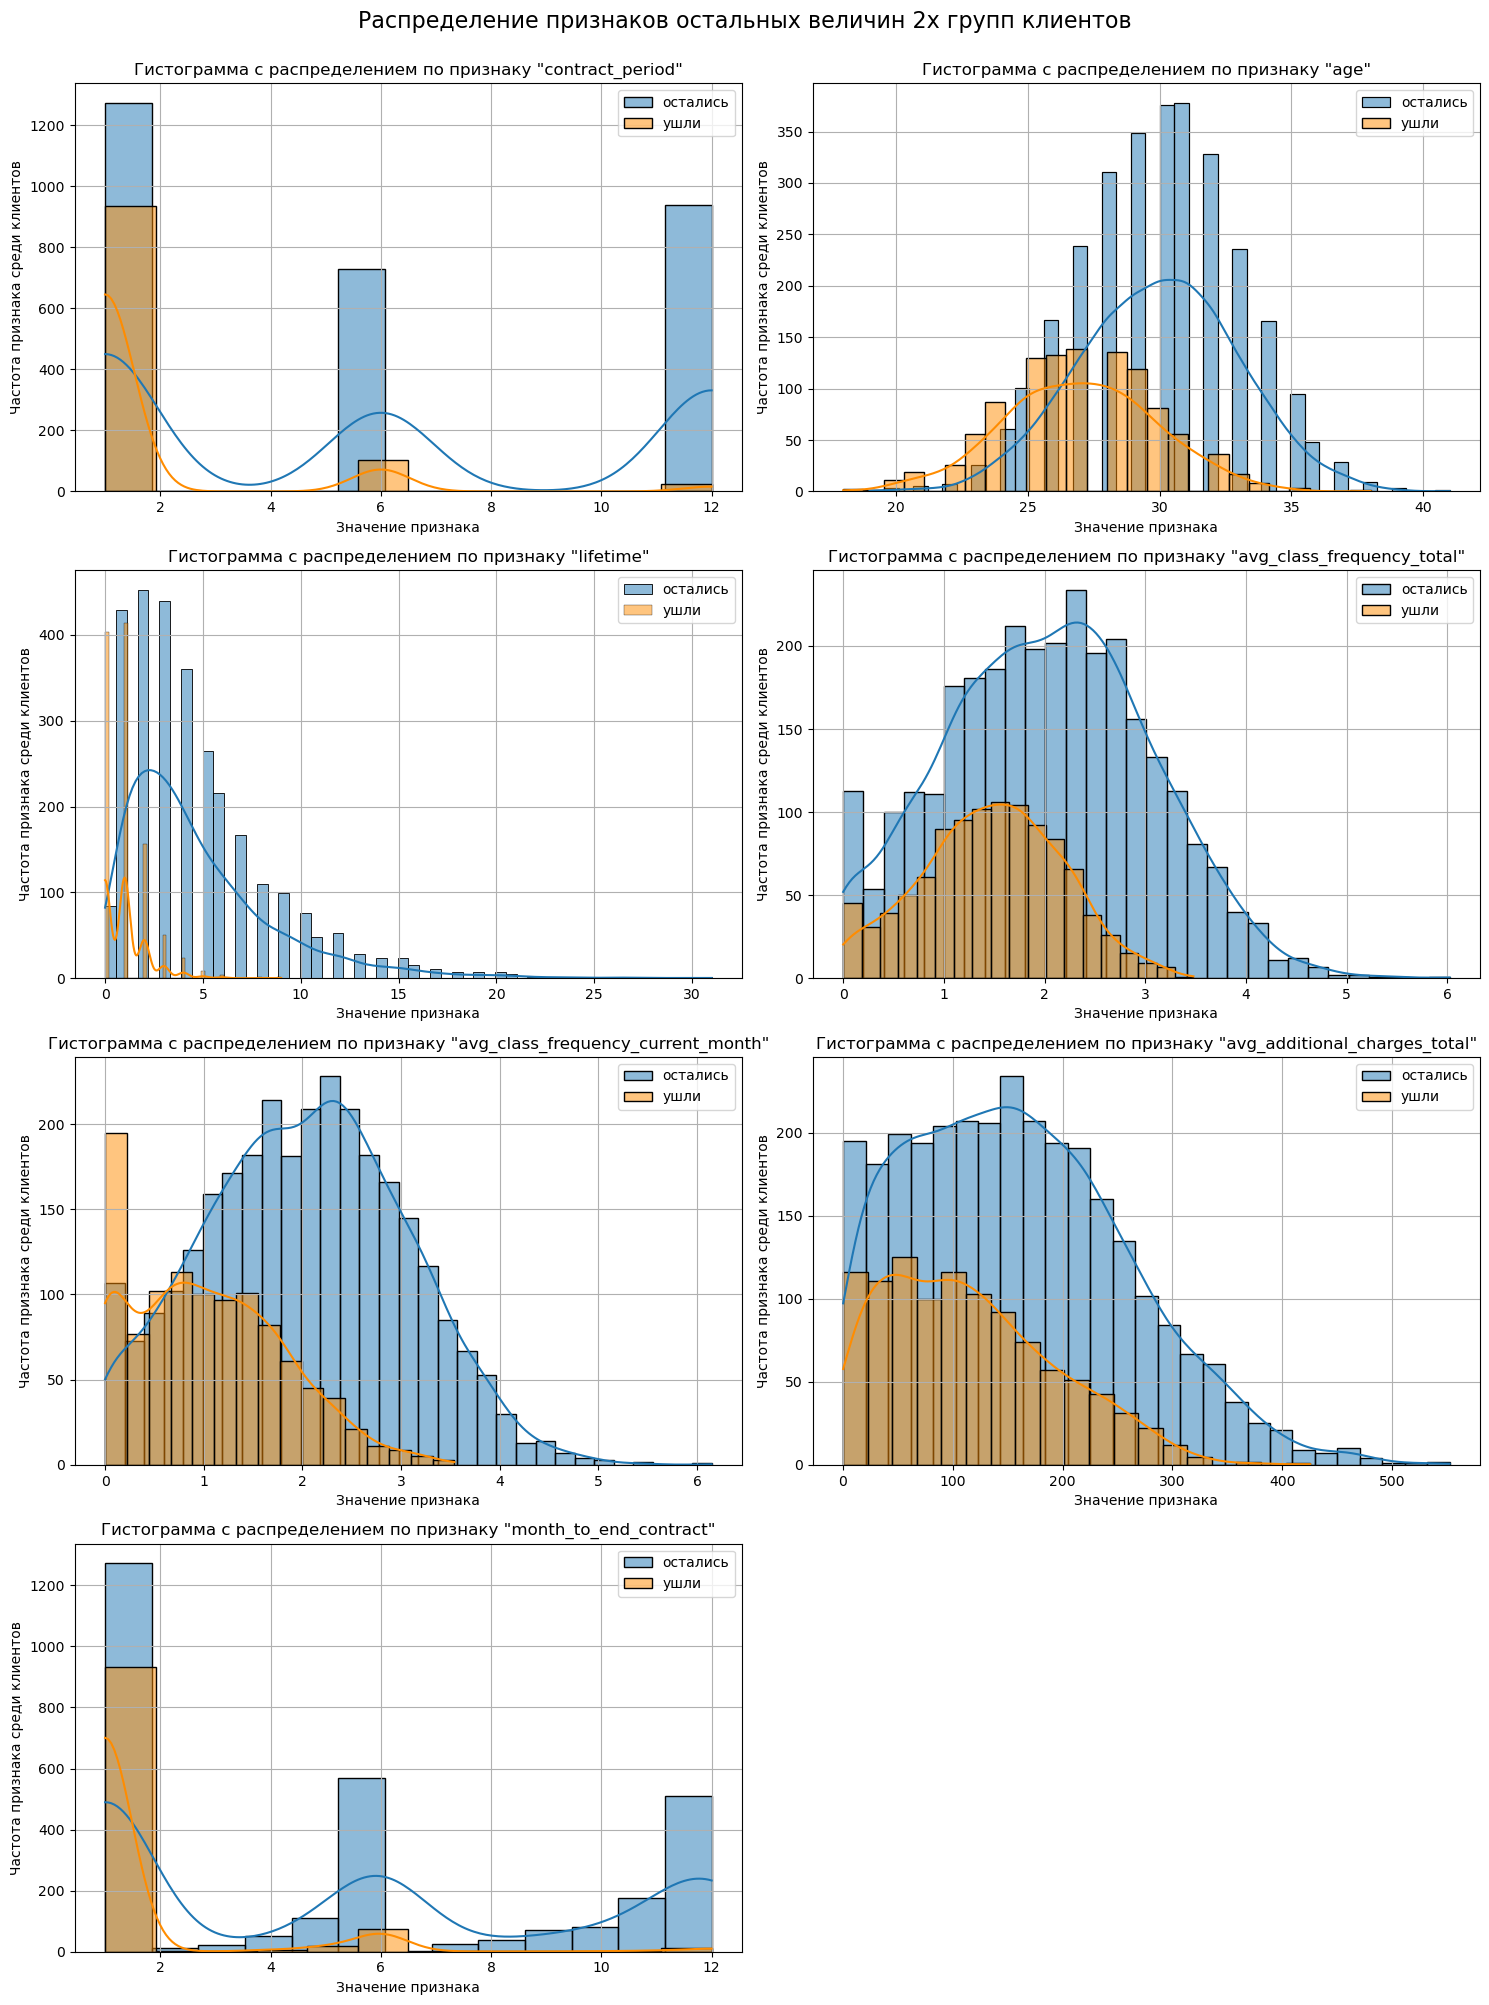

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20)) 
fig.suptitle('Распределение признаков остальных величин 2х групп клиентов', fontsize=16, y=1)

values = [ 
    'contract_period', 'age', 'lifetime', 'avg_class_frequency_total', 
    'avg_class_frequency_current_month', 'avg_additional_charges_total',
    'month_to_end_contract'
]

for idx, column in enumerate(values):
    # Определяем позицию подграфика
    row = idx // 2
    col = idx % 2
    ax = axes[row, col] # Выбираем текущий подграфик
    
    sns.histplot(
        clients.loc[clients['churn'] == 0, column],
        kde=True, 
        label='остались', 
        alpha=0.5, 
        ax=ax
    )
    sns.histplot(
        clients.loc[clients['churn'] == 1, column],
        kde=True, 
        label='ушли', 
        alpha=0.5,
        ax=ax,
        color='DarkOrange'
    )
    
    ax.set_ylabel('Частота признака среди клиентов')
    ax.set_xlabel('Значение признака')
    ax.set_title(f'Гистограмма с распределением по признаку "{column}"')
    ax.grid()
    ax.legend()

# Уберем лишний пустой подграфик
if len(values) < 8:
    fig.delaxes(axes[3, 1])

plt.tight_layout()
plt.grid(True)
plt.show()

***В результате графиков можно выделить следующие закономерности:***

Реже попадают в отток клиенты, которые:

- проживают или работают в районе местонахождения фитнес-центра
- сотрудники компаний-партнеров клуба и участники акции "Приведи друга"
- оставили при покупке абонемента свой контактный номер телефона
- приобретают абонемент на более длительный срок
- посещают групповые занятия
- в возрасте около 30 лет
- приобретают дополнительные услуги

Чаще попадают в отток клиенты:
- у которых меньше времени остается до конца абонемента
- в возрасте около 27 лет
- с меньшим количеством посещений в среднем в неделю
- которые не особо тратятся на дополнительные услуги клуба
- у которых приобретен абонемент на короткий срок

Не особо влияет на долю оттока клиентов:
- пол клиентов

### 2.4. Построим матрицу корреляций и отобразим её.

In [29]:
cm = clients.corr()
cm

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
near_location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


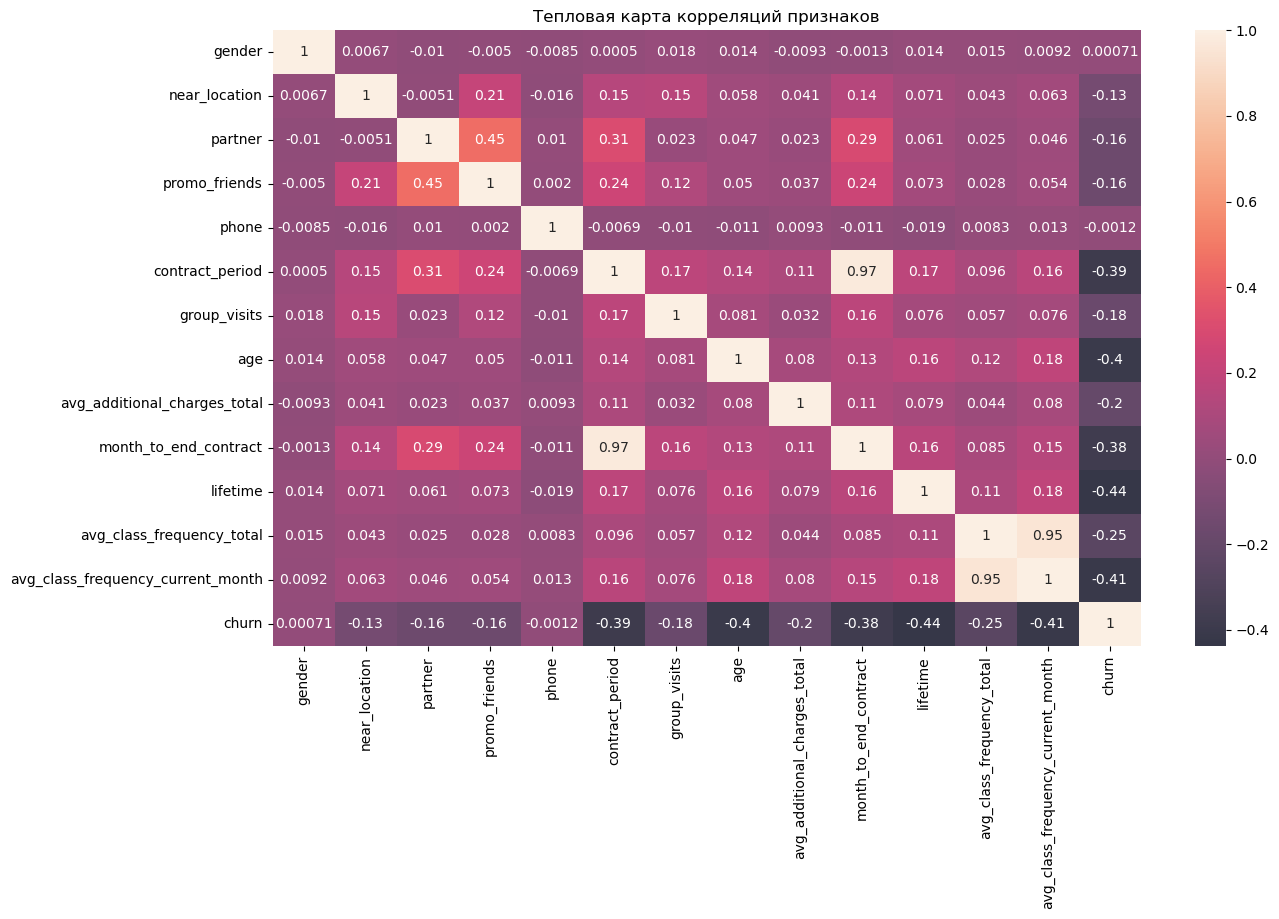

In [30]:
plt.figure(figsize=(14, 8))
sns.heatmap(cm, annot=True, alpha=0.8)

plt.title('Тепловая карта корреляций признаков')
plt.show()

***Судя по тепловой карте, наблюдается следующая корреляция оттока клиентов:***

- очень слабая, практически нулевая корреляция у признаков `gender` и `phone`
- слабая корреляция у признаков `near_location`, `partner`, `promo_friends`, `group_visits`, `avg_additional_charges_total` и `avg_class_frequency_total`
- умеренная корреляция у признаков `contract_period`, `age`, `month_to_end_contract`, `lifetime` и `avg_class_frequency_current_month`.

***Также нужно будет обратить внимание на следующие пары признаков, между которыми есть сильная зависимость - это пары `contract_period` и `month_to_end_contract` (0,97), а также `avg_class_frequency_total` и `avg_class_frequency_current_month` (0,95). Это говорит о мультиколлинеарности, поэтому для объективной работы модели нужно будет избавиться от одного из этих признаков.***

In [33]:
model_clients = clients.drop('contract_period', axis=1)
model_clients = clients.drop('avg_class_frequency_total', axis=1)

***ВЫВОДЫ:***

1. В ходе предобработки данных мы выяснили, что пропусков и дубликатов в данных нет.
2. Названия столбцов, которые начинались с больших букв, мы привели к нижнему регистру.
3. Изучив средние значения столбца `age`, мы выяснили, что самые младшие клиенты клуба находятся в возрасте 18 лет, самым старшим клиентам клуба - 41 год.
4. Изучив средние значения столбцов `avg_class_frequency_total` и `avg_class_frequency_current_month`, мы выяснили, что есть клиенты, которые за все время действия абонемента и за последний месяц вовсе не посещали зал, а есть те, которые приходили в зал в среднем 6 раз в неделю.
5. На отток клиентов не особо влияет такой признак, как пол.
6. Есть признаки, которые влияют на отток клиентов в той или иной мере.
7. Реже попадают в отток клиенты, которые проживают или работают рядом с клубом, участники реферальных акций, приобретают абонементы на более длительный срок, приобретают больше дополнительных услуг.
8. Чаще попадают в отток клиенты, которые посещают зал в среднем меньше двух раз в неделю, у которых остается мало времени (чаще меньше месяца до окончания срока абонемента), и которые не особо тратятся на дополнительные услуги клуба.
9. Обнаружили две пары признаков, между которыми наблюдается сильная корреляция и для объективной работы модели мы их учитывать не будем.

# Шаг 3. Построение модели прогнозирования оттока клиентов

Построим модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце.

### 3.1. Разобьем данные на обучающую и валидационную выборку функцией train_test_split().

Импортируем необходимые нам для построения модели библиотеки:

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

Разделим наши данные на признаки (матрица X) и целевую переменную (y):

In [41]:
X = model_clients.drop(columns=['churn'], axis=1)
y = model_clients['churn']

Разделим данные на обучающую и валидационную выборку:

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### 3.2. Обучим модель на train-выборке двумя способами: логистической регрессией и случайным лесом.

Стандартизируем данные:

In [46]:
# создадим объект класса StandardScaler и применим его к обучающей выборке
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train) #обучаем scaler и одновременно трансформируем матрицу для обучающей выборки
#применяем стандартизацию к матрице признаков для тестовой выборки
X_test_st = scaler.transform(X_test)

Обучим модель на обучающей выборке двумя необходимыми способами:

In [48]:
# задаем алгоритм для нашей модели, сначала логистическая регрессия
LR_model = LogisticRegression(solver='liblinear', random_state=0)
# обучение модели
LR_model.fit(X_train_st, y_train)
# воспользуйтесь уже обученной моделью, чтобы сделать прогнозы
LR_predictions =  LR_model.predict(X_test_st)
LR_probabilities = LR_model.predict_proba(X_test_st)[:,1]

# задаем алгоритм для нашей модели, случайный лес
RF_model = RandomForestClassifier(random_state=0)
RF_model.fit(X_train_st, y_train)
RF_predictions =  RF_model.predict(X_test_st)
RF_probabilities = RF_model.predict_proba(X_test_st)[:,1]

### 3.3. Оценим метрики accuracy, precision и recall для обеих моделей на валидационной выборке и сравним по ним модели. 

Выясним, какая модель показала себя лучше на основании метрик? Сначала выведем метрики для модели логистической регрессии:

In [51]:
print ('Метрики для модели логистической регрессии')
print ('accuracy = ', round(accuracy_score(y_test, LR_predictions), 2))
print ('precision = ', round(precision_score(y_test, LR_predictions), 2))
print ('recall = ', round(recall_score(y_test, LR_predictions), 2))
print ('f1_score = ', round(f1_score(y_test, LR_predictions), 2))
print ('roc_auc_score = ', round(roc_auc_score(y_test, LR_probabilities), 2))

Метрики для модели логистической регрессии
accuracy =  0.92
precision =  0.83
recall =  0.88
f1_score =  0.85
roc_auc_score =  0.97


***Модель показала достаточно хорошие результаты, accuracy - доля правильных ответов (91%) показала, что модель хорошо справляется с предсказанием обоих классов, precision - точность (83%) показывает, что модель хорошо предсказывает ушедших клиентов, минимизируя ложные срабатывания (FP) (если стоимость удержания клиентов высока, precision можно считать хорошим результатом), и наконец recall - полнота (85%) показывает, что модель хорошо идентифицирует ушедших клиентов, минимизируя пропуски (FN) (если важно не пропустить ушедших клиентов, Recall можно считать хорошим результатом).***

***F1_score (гармоническое среднее precision и recall) в 84% говорит о хорошем балансе между precision и recall, что указывает на устойчивость модели, а roc_auc_score (площадь под roc-кривой) это отличный результат, который подтверждает, что модель хорошо разделяет два класса.***

In [53]:
print ('Метрики для модели случайного леса')
print ('accuracy = ', round(accuracy_score(y_test, RF_predictions), 2))
print ('precision = ', round(precision_score(y_test, RF_predictions), 2))
print ('recall = ', round(recall_score(y_test, RF_predictions), 2))
print ('f1_score = ', round(f1_score(y_test, RF_predictions), 2))
print ('roc_auc_score = ', round(roc_auc_score(y_test, RF_probabilities), 2))

Метрики для модели случайного леса
accuracy =  0.92
precision =  0.86
recall =  0.83
f1_score =  0.84
roc_auc_score =  0.97


***Модель случайного леса показывает хорошие результаты: accuracy = 91% (модель показывает такую же высокую точность, что и логистическая регрессия), precision = 86% (случайный лес лучше справляется с минимизацией ложных срабатываний (FP) по сравнению с логистической регрессией), recall = 79% (recall у случайного леса ниже, чем у логистической регрессии, и это означает, что модель пропускает больше ушедших клиентов).***

***Одинаковое значение в f1_score с моделью логистической регрессией, данная модель также устойчива, по показателю roc_auc_score логистическая регрессия немного лучше (98% против 97%), однако случайный лес также хорошо разделяет два класса.***

***ВЫВОДЫ:***

1. Мы построили две модели для прогнозирования оттока клиентов - логистическая регрессия и случайный лес.
2. Обе модели показали себя достаточно неплохо и на них вполне можно делать приемлемые прогнозы.
3. По сравнению с логистической регрессией, случайный лес лучше по precision и roc_auc_score , но хуже по recall. 

# Шаг 4. Кластеризация клиентов

### 4.1. Стандартизируем данные

Отбросим перед этим столбец `churn`:

In [59]:
X = clients.drop(columns=['churn'], axis=1)

In [60]:
# обязательная стандартизация данных перед работой с алгоритмами
sc = StandardScaler()
X_sc = sc.fit_transform(X)

### 4.2. Построим матрицу расстояний функцией linkage() на стандартизованной матрице признаков и нарисуем дендрограмму.

Передадим получившуюся стандартизированную таблицу в качестве параметра функции `linkage()`. Чтобы диаграмма получилась показательной, передадим параметру `method` значение `ward`:

In [63]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_sc, method = 'ward')

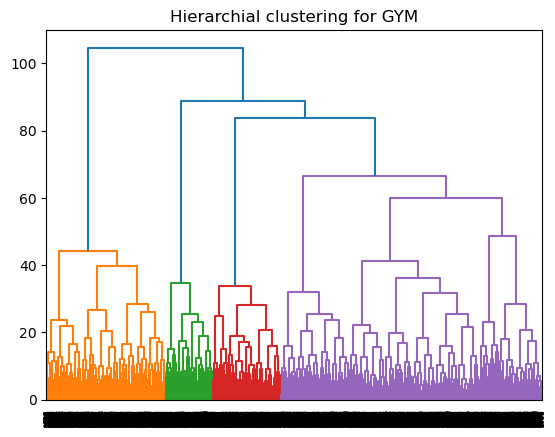

In [64]:
dendrogram(linked, orientation='top')
plt.title('Hierarchial clustering for GYM')
plt.show()

***Предложенное оптимальное число кластеров 5. Визуально можно было бы выбрать как раз 4 кластера, потому что на графике 4 разных цвета как раз, однако по заданию выберем 5.***

### 4.3. Обучим модель кластеризации на основании алгоритма K-Means и спрогнозируем кластеры клиентов.

In [67]:
# задаём модель k_means с числом кластеров 5 и фиксируем значение random_state
km = KMeans(n_clusters=5, random_state=0)
# прогнозируем кластеры для наблюдений (алгоритм присваивает им номера от 0 до 2)
labels = km.fit_predict(X_sc)

  File "C:\Users\etols\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\etols\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\etols\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\etols\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [68]:
# сохраняем метки кластера в поле нашего датасета
clients['cluster_km'] = labels
clients.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,cluster_km
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,3
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,2
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,2
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,3


### 4.4. Посмотрим на средние значения признаков для кластеров.

In [70]:
print('Средние значения признаков по кластерам:')
display(clients.groupby('cluster_km').mean().T)

Средние значения признаков по кластерам:


cluster_km,0,1,2,3,4
gender,0.486819,0.592493,0.499469,0.483360,0.496324
near_location,1.000000,0.970509,0.943677,1.000000,0.000000
partner,0.243409,0.288204,0.740701,0.798732,0.466912
promo_friends,0.007030,0.123324,0.489904,1.000000,0.077206
phone,0.899824,0.898123,0.900106,0.911252,0.915441
contract_period,1.978910,2.898123,11.866100,3.079239,2.209559
group_visits,0.326889,0.482574,0.551541,0.445325,0.215074
age,28.239016,30.339142,29.905420,29.052298,28.483456
avg_additional_charges_total,130.877033,164.193829,165.146492,139.858265,133.630215
month_to_end_contract,1.896309,2.654155,10.852285,2.873217,2.073529


***Посмотрев на средние значения признаков для кластеров можно заметить следующее:***

**Кластер 0:**
- 100% клиентов проживают или работают рядом с фитнес-центром
- только 24.3% клиента пришли по реферальной программе
- низкий показатель (0.7%) — клиенты редко привлекали друзей по акции
- средняя длительность абонемента — около 2 месяцев.
- около 33% клиентов данного кластера посещают групповые занятия
- осталось около 1.9 месяцев до конца абонемента
- высокий уровень оттока — 51.3%.

***Можно сказать, что клиенты данного кластера - это клиенты с короткими абонементами, которые проживают или работают рядом с фитнес-центром, но редко привлекают друзей и не участвуют в партнерских программах. Высокий уровень оттока может быть связан с коротким сроком абонементов и отсутствием вовлеченности в программы лояльности.***

**Кластер 1:**
- 97% клиентов проживают или работают рядом с фитнес-центром
- только 28.8% клиентов пришли по реферальной программе
- 12,3% клиентов привлекали друзей по акции
- средняя длительность абонемента — около 2,9 месяцев
- почти 50% клиентов данного кластера посещают групповые занятия
- осталось около 2,7 месяцев до конца абонемента
- умеренная частота посещений - в среднем почти 3 раза в неделю
- очень низкий уровень оттока — 5.5%.

***Это активные клиенты, которые часто посещают фитнес-центр, проживают или работают рядом с ним и отчасти участвуют в партнерских программах. Низкий уровень оттока связан с высокой лояльностью и частотой посещений.***

**Кластер 2:**
- 94.4% клиентов проживают или работают рядом с фитнес-центром
- очень большой показатель клиентов по партнерской программе - 74.1% клиентов
- почти 50% клиентов привлекали друзей по акции
- самые долгосрочные абонементы — почти годовые (11,9 месяцев)
- более 50% клиентов данного кластера посещают групповые занятия
- осталось около 10,9 месяцев до конца абонемента
- умеренная частота посещений - в среднем около 2 раз в неделю
- очень низкий уровень оттока — 2,2%.

***Это лояльные клиенты с долгосрочными абонементами, которые активно участвуют в партнерских программах и часто рекомендуют фитнес-центр друзьям. Низкий уровень оттока связан с долгосрочными абонементами и высокой вовлеченностью.***

**Кластер 3:**
- 100% клиентов проживают или работают рядом с фитнес-центром
- достаточно высокий показатель клиентов по партнерской программе - 47% клиентов
- 100% клиентов привлекали друзей по акции
- достаточно долгосрочные абонементы — 3 месяца
- 45% клиентов данного кластера посещают групповые занятия
- осталось около 2,9 месяцев до конца абонемента
- умеренная частота посещений - в среднем 1,7 раз в неделю
- средний уровень оттока — 26,9%.

***Это клиенты, которые активно участвуют в партнерских программах и привлекают друзей, но имеют средний уровень оттока. Возможно, их вовлеченность в программы лояльности недостаточно сильна для удержания.***

**Кластер 4:**
- никто из клиентов не проживает или работает рядом с фитнес-центром
- очень большой показатель клиентов по партнерской программе - 80% клиентов
- 77% клиентов привлекали друзей по акции
- длительность абонементов — 2,2 месяца
- всего 21,5% клиентов данного кластера посещают групповые занятия
- осталось около 2,1 месяца до конца абонемента
- умеренная частота посещений - в среднем 1,7 раз в неделю
- высокий уровень оттока — 45%.

***Это клиенты, которые проживают и не работают рядом с фитнес-центром и редко привлекают друзей. Высокий уровень оттока может быть связан с неудобным расположением фитнес-центра и низкой вовлеченностью.***

Оценим проведенную кластеризацию с помощью метрики `silhouette_score`:

In [73]:
print('silhouette_score = ', silhouette_score(X_sc, labels))

silhouette_score =  0.12857651761657582


***Чем ближе метрика к значению 1, тем качественнее кластеризация, однако в нашем случае метрика приняла значение 0,13, значит возможна и более удачная кластеризация, чем у нас.***

### 4.5. Построим распределения признаков для кластеров. 

Для булевых значений достаточно наглядно построить столбчатые диаграммы, а для всех остальных - попробуем построить "ящики с усами":

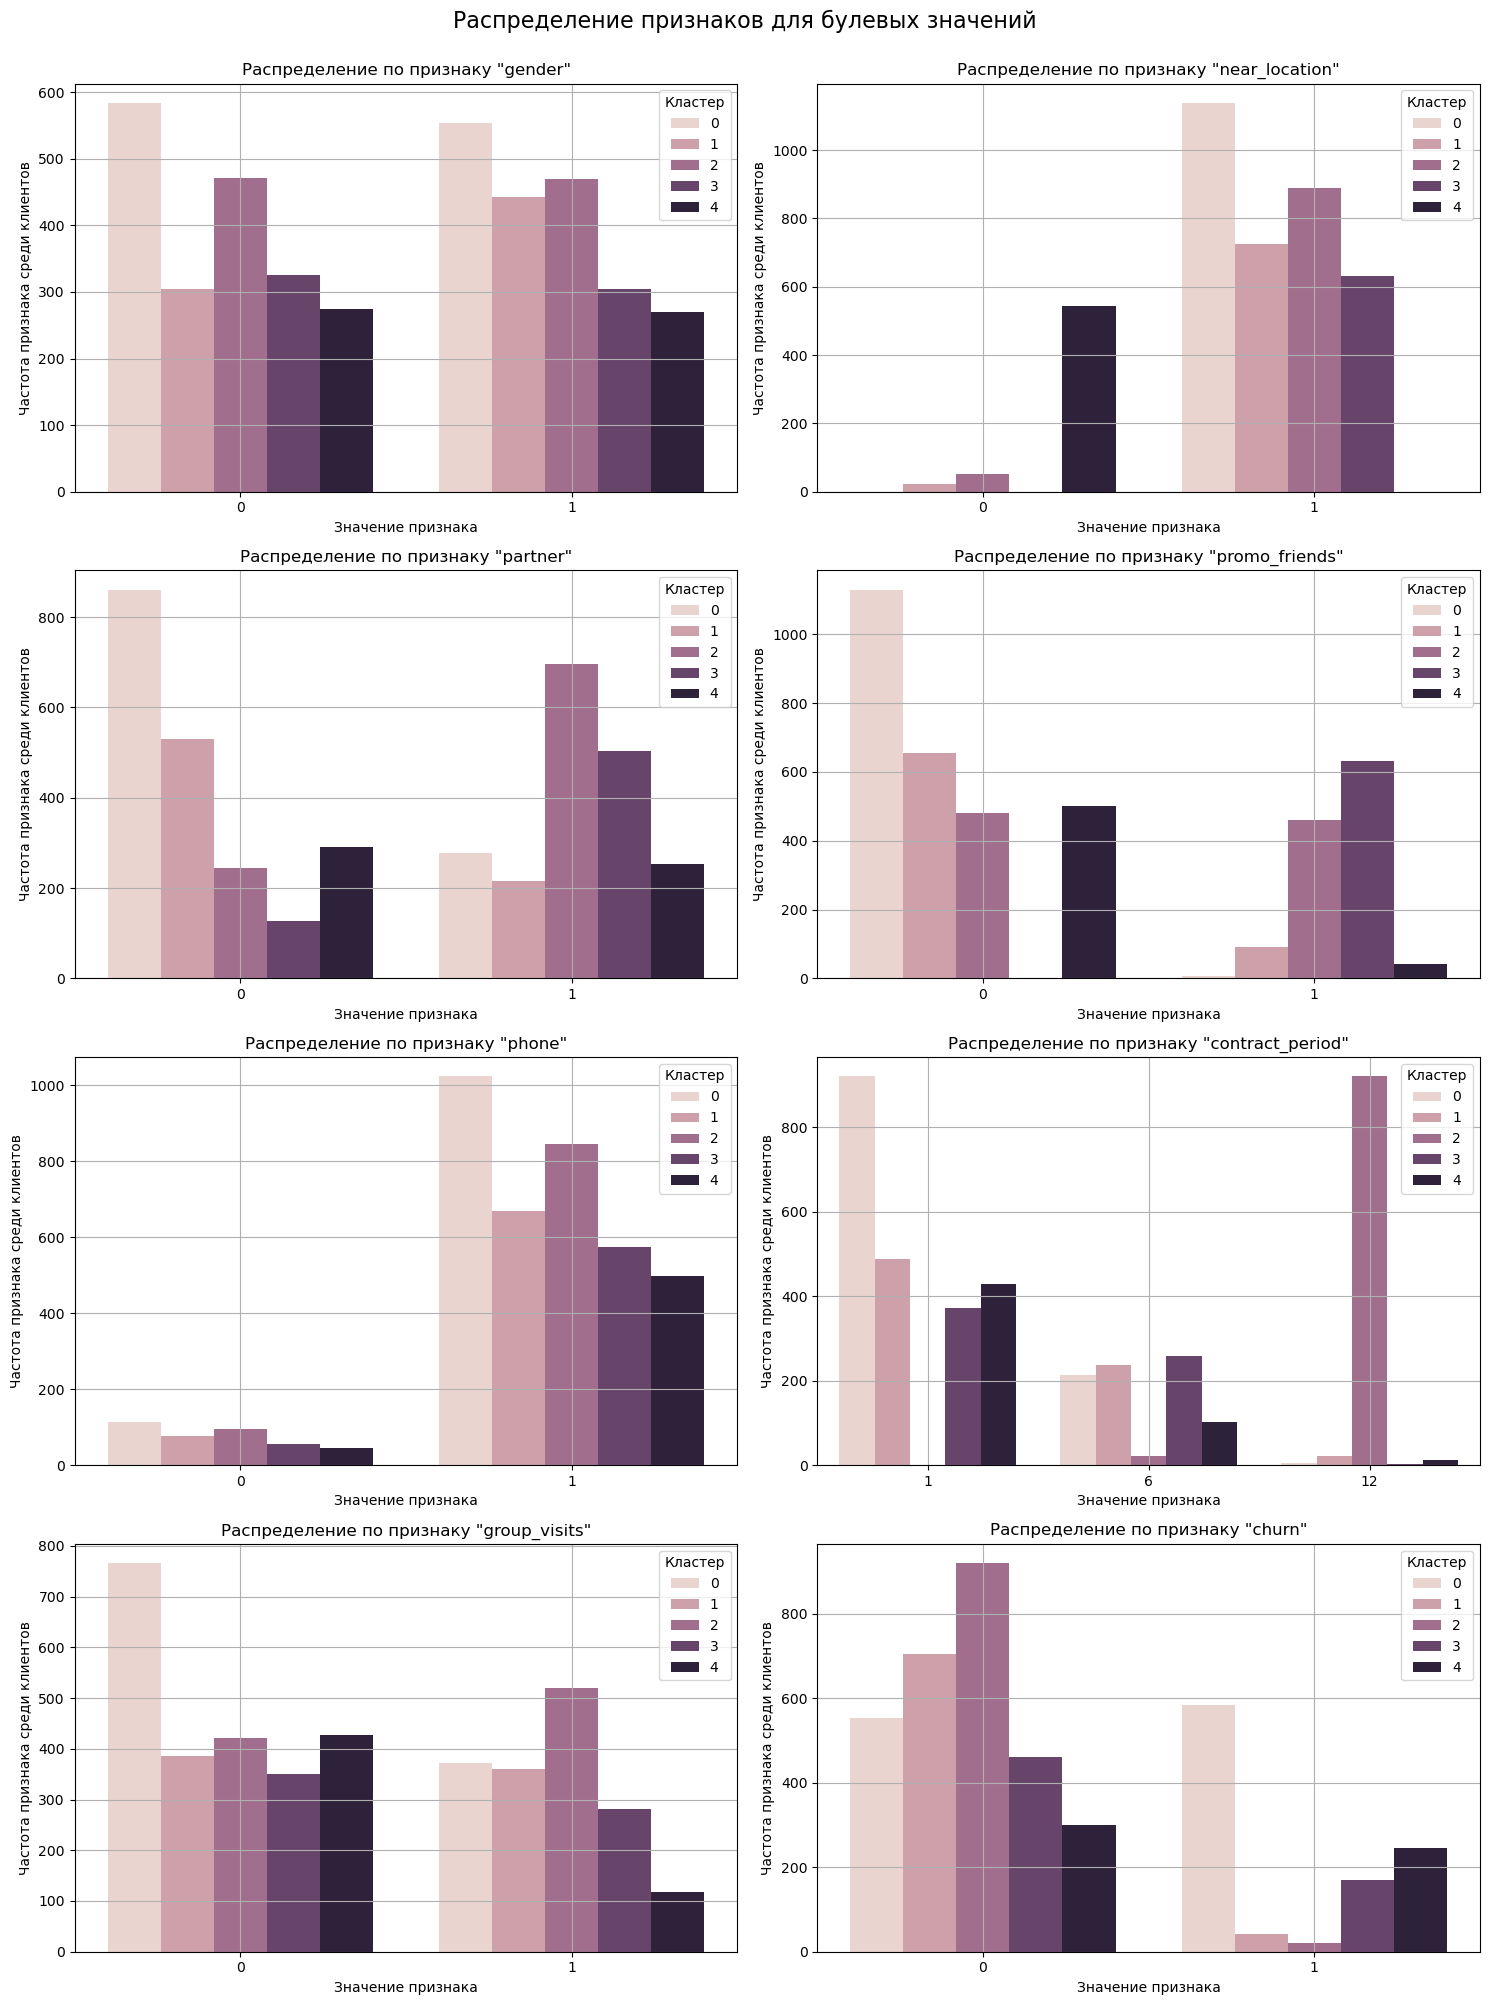

In [77]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20)) 
fig.suptitle('Распределение признаков для булевых значений', fontsize=16, y=1)

values = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'contract_period', 'group_visits', 'churn']

# Проходим по всем признакам и строим графики
for idx, column in enumerate(values):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    sns.countplot(x=clients[column], hue='cluster_km', data=clients, ax=ax)
    
    ax.set_ylabel('Частота признака среди клиентов')
    ax.set_xlabel('Значение признака')
    ax.set_title(f'Распределение по признаку "{column}"')
    ax.grid(True)
    ax.legend(title='Кластер')

plt.tight_layout()  # Автоматическая настройка отступов
plt.show()

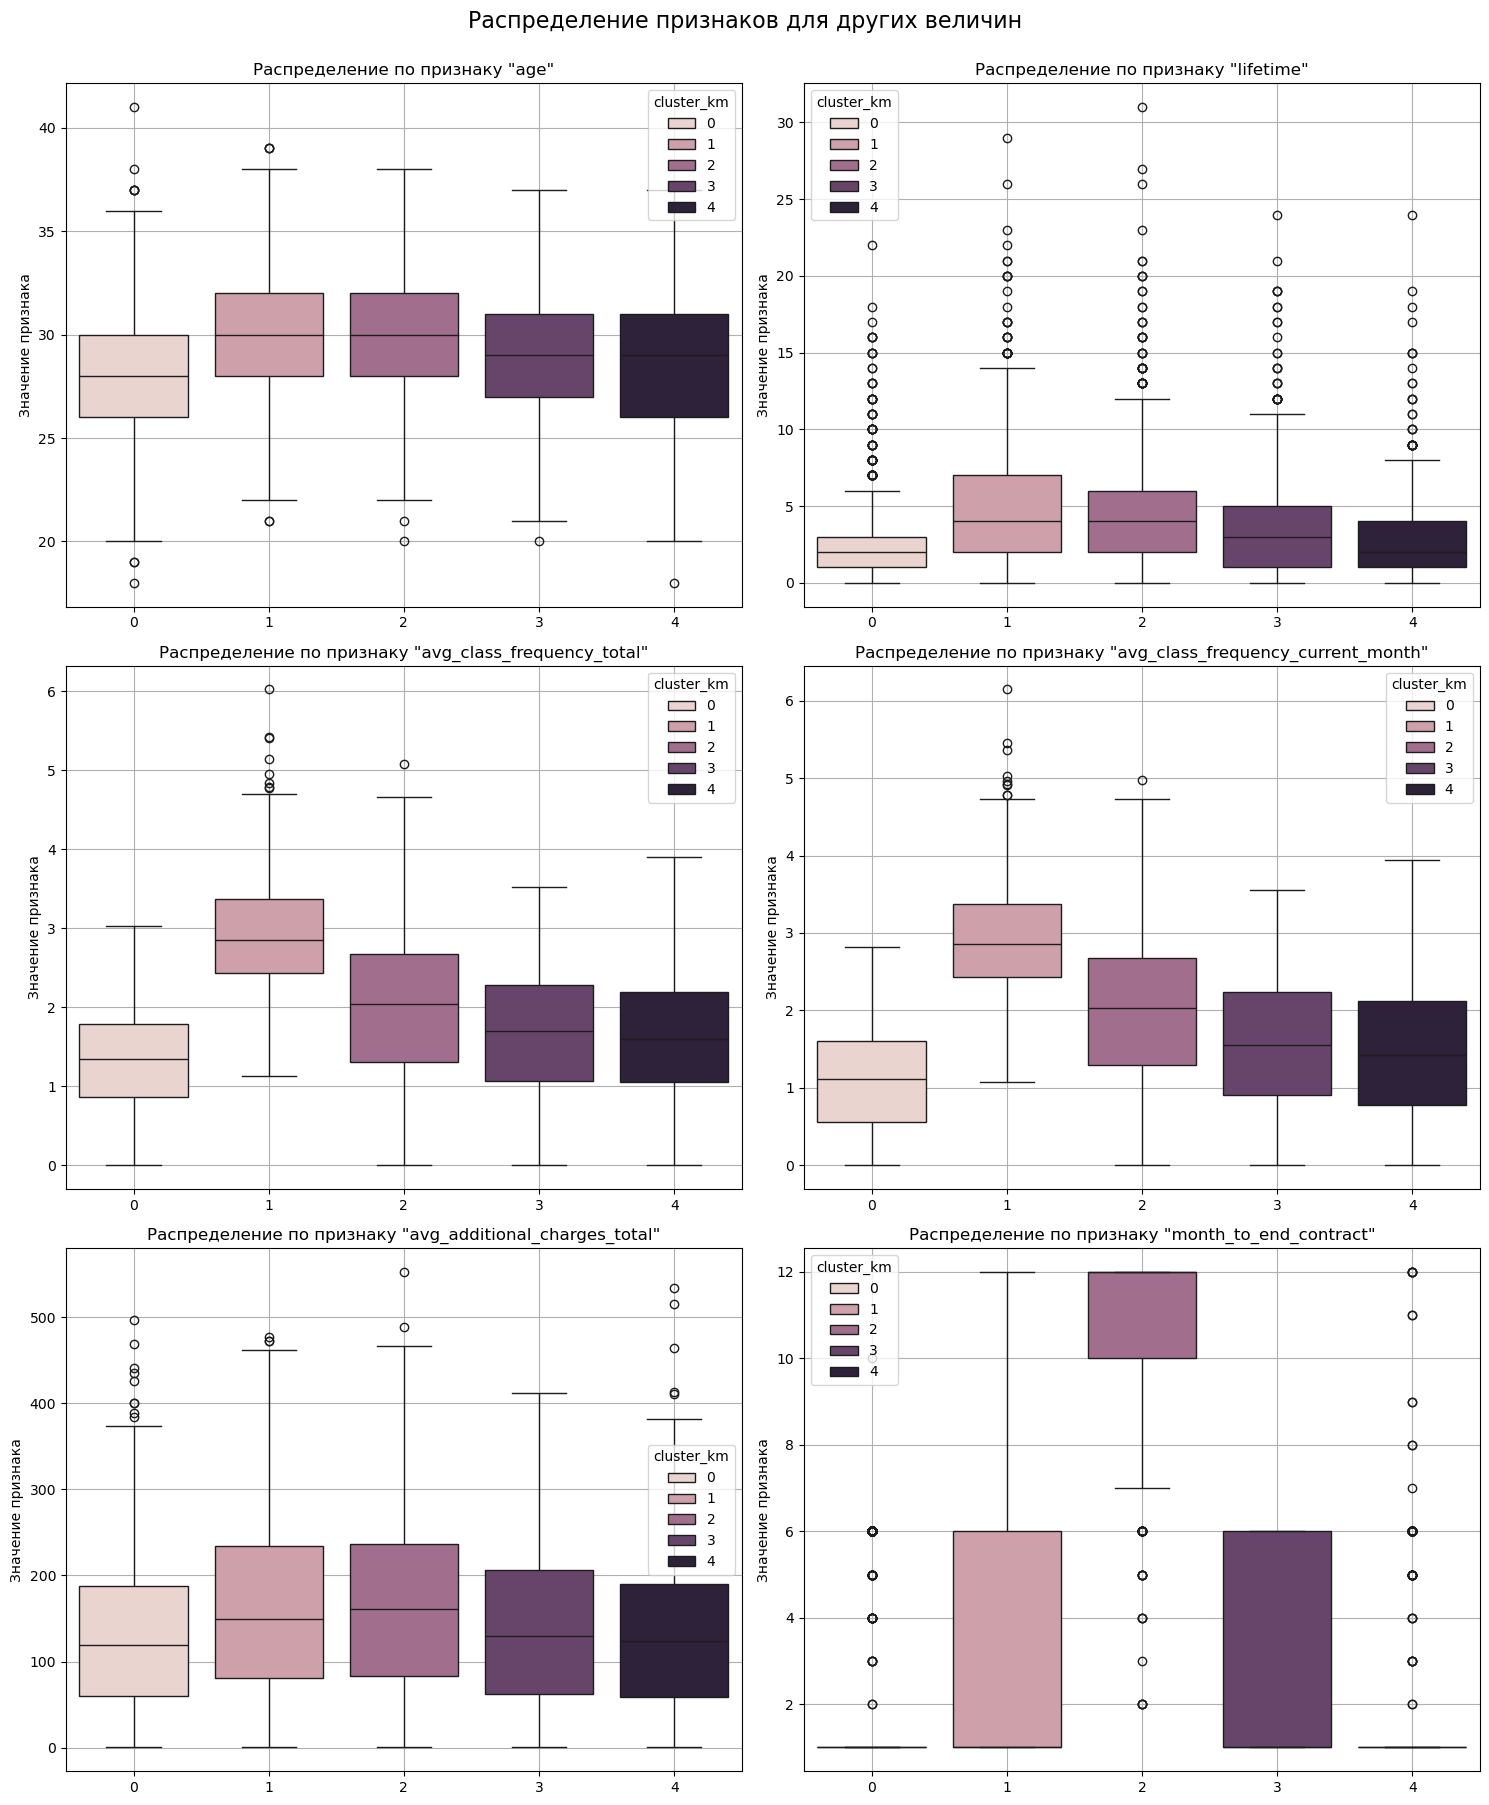

In [78]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
fig.suptitle('Распределение признаков для других величин', fontsize=16, y=1)

values = [
    'age', 'lifetime', 'avg_class_frequency_total', 
    'avg_class_frequency_current_month', 'avg_additional_charges_total',
    'month_to_end_contract'
]

# Проходим по всем признакам и строим графики
for idx, column in enumerate(values):
    row = idx // 2 
    col = idx % 2 
    ax = axes[row, col] 
    
    sns.boxplot(x = 'cluster_km', y = clients[column], data = clients, ax=ax, hue='cluster_km')
    
    ax.set_ylabel('Значение признака')
    ax.set_xlabel('')
    ax.set_title(f'Распределение по признаку "{column}"')
    ax.grid(True)

# Убираем лишние пустые подграфики, если количество признаков нечетное
if len(values) < 6:
    for idx in range(len(values), 6):
        row = idx // 2
        col = idx % 2
        fig.delaxes(axes[row, col])

plt.tight_layout()  # Автоматическая настройка отступов
plt.show()

***В результате построенных графиков можно увидеть следующее:***

- только для клиентов из кластера 4 неудобно расположение фитнес-центра
- кластеры 2 и 3 в основном приходят по партнерской программе, 0 и 1 - больше без партнерки, 4 кластер - примерно поровну
- советуют друзьям в основном клиенты из 3 кластера, кластеры 0, 1, 4 - реже советуют друзьям фитнес-центра, кластер 2 примерно поровну
- самый долгосрочный абонемент на 12 месяцев приобретают в основном клиенты кластера 2
- чаще всего отваливаются клиенты из кластера 0
- кластер 2 чаще всех в среднем раз в неделю посещает фитнес-центр
- у клиентов из кластера 2 больше всего времени до окончания абонемента, кластеры 0 и 4 - осталось меньше всего времени осталось до конца абонемента

### 4.6. Для каждого полученного кластера посчитаем долю оттока (методом groupby()).

Отличаются ли кластеры по доле оттока? Какие кластеры склонны к оттоку, а какие — надёжны?

In [82]:
churn_share = clients.query('churn==1').groupby('cluster_km')['churn'].count() / clients.query('churn==1')['churn'].count()
round(churn_share, 2)

cluster_km
0    0.55
1    0.04
2    0.02
3    0.16
4    0.23
Name: churn, dtype: float64

Для наглядности построим круговую диаграмму долей оттока кластеров:

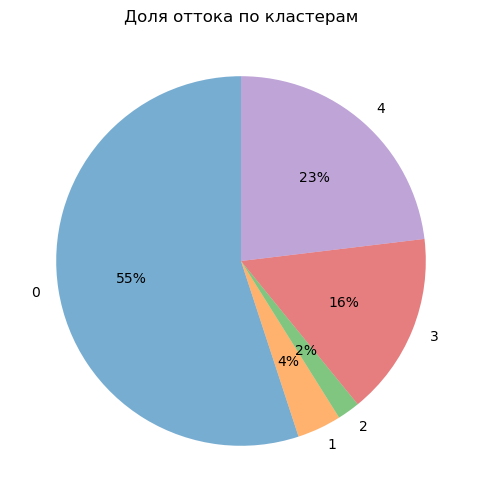

In [84]:
plt.figure(figsize=(6, 6))

plt.pie(
    churn_share,
    labels=churn_share.index,
    autopct='%.0f%%',
    startangle=90,
    wedgeprops={'alpha': 0.6}
)
plt.title('Доля оттока по кластерам', fontsize=12)
plt.show()

***Самый большой показатель оттока у клиентов из 0 кластера (55%), а также достаточно высокий показатель у кластера 4 (23%), далее средний показатель оттока у клиентов кластера 3 (16%), и самые низкие показатели оттока у кластеров - 1 и 2 (4% и 2%).***

***ВЫВОДЫ:***

1. Мы сделали кластеризацию на основании алгоритма K-means, спрогнозировали кластеры клиентов и посмотрели на средние значения признаков для кластеров.
2. Мы выявили кластеры с самым высоким оттоком (0 и 4): к ним относятся клиенты с краткосрочными абонементами, низкой вовлеченностью в партнерские программы, низкой лояльностью и неудобным для них расположением фитнес-центра.
3. Нашли кластер с умеренным оттоком - "золотую серединку" - это клиенты, которые активно участвуют в реферальных программах, максимально активно рекомендуют фитнес-центр друзьям, но имеют средний уровень оттока.
3. Есть кластеры с низким уровнем оттока клиентов (1 и 2): сюда отнесены клиенты с высокой вовлеченностью, лояльностью, самыми долгосрочными абонементами и активным участием в партнерских программах.
4. Потенциальная характеристика клиента с высоким уровнем оттока - это люди в возрасте около 27 лет, которые в принципе изначально приобретают абонементы на короткий срок и у которых очень мало остается до конца абонемента, они мало или совсем не тратят на дополнительные услуги клуба, а также у них меньше в среднем посещений клуба в неделю.

# Шаг 5. Формулировка выводов и базовых рекомендаций по работе с клиентами

Сформулируем основные выводы и предложим рекомендации для стратегии взаимодействия с клиентами и их удержания. 

***Загрузка и исследовательский анализ данных:***

В ходе предобработки данных мы изучили имеющиеся в нашем распоряжении данные, дубликатов и пропусков в данных нет. Единственное, что мы привели к нижнему регистру названия столбцов нашего датасета.
Самые младшие клиенты клуба находятся в возрасте 18 лет, самым старшим клиентам клуба - 41 год. В данных есть клиенты, которые за все время действия абонемента и за последний месяц вовсе не посещали зал, а есть те, которые приходили в зал в среднем 6 раз в неделю.

***Построение моделей прогнозирования оттока клиентов:***

Мы использовали для прогнозирования две модели - логистическая регрессия и случайный лес, в итоге мы выяснили, что обе модели показали себя достаточно неплохо и на них вполне можно делать приемлемые прогнозы. По сравнению с логистической регрессией, случайный лес лучше по показателям precision и roc_auc_score, но хуже по recall.

***Кластеризация клиентов:***
Мы выявили кластеры с самым высоким оттоком (0 и 4 - показатели оттока составляют 55% и 23% соответственно), с умеренным (3, отток - 16%) - "золотую середину" и кластеры с самым низким оттоком (1 и 2 - показатели оттока - 4% и 2% соответственно). 

**Потенциальная характеристика клиента с высоким уровнем оттока:**

- это люди в возрасте около 27 лет
- изначально приобретают абонементы на короткий срок
- у них очень мало остается до конца абонемента
- мало или совсем не тратят на дополнительные услуги клуба
- у них меньше в среднем посещений клуба в неделю.

***Рекомендации по работе с клиентами:***

- для кластеров с высоким оттоком: предлагать скидки/ акции на долгосрочные абонементы, по возможности улучшить транспортную доступность, либо как вариант предложить проведение онлайн-тренировок для тех клиентов, которые не проживают и не работают в близлежащих к фитнес-центру районах, разнообразить групповые тренировки, поскольку среди посещающих групповые тренировки клиентов есть тенденция к меньшему показателю оттока.)
- для кластеров с низким оттоком: продолжать вовлекать их в программы лояльности, предлагать дополнительные услуги клуба (например, персональные тренировки), предложить дополнительные бонусы для удержания, поддерживать высокий уровень сервиса, чтобы не разочаровать постоянных клиентов, предлагать постоянным клиентам индивидуальные скидки на долгосрочные абонементы, устраивать различные активности (межклубные соревнования со скидками на персональные тренировки для постоянных клиентов), наращивать объемы партнерской программы в организациях.
- для кластера с умеренным оттоком: усилить программы лояльности и предложить дополнительные бонусы за привлечение друзей.